# InSilicoICH: Part 3. Running Studies

This notebook combines the pieces from [01_phantoms.ipynb](01_phantoms.ipynb) and [02_scanners.ipynb](02_scanners.ipynb) into the full pipeline, checkout those notebooks for more in depth coverage of each

This notebook introduces the `ICHStudy` class, which is an extension of the VITools Study class used to run studies with the phantoms and scanners defined in the previous notebooks. ICHStudy is a subclass of the VITools Study class, which provides additional functionality for adding intracranial hemorrhage (ICH) phantoms, metadata and measurements to the study. It also includes methods for running the study and generating reports.

In [1]:
from insilicoICH.study import ICHStudy
ICHStudy?

Init signature: ICHStudy(input_csv: pandas.core.frame.DataFrame | str | None = None)
Docstring:      Manages the generation and execution of in silico ICH virtual trials.
Init docstring:
Initializes a Study instance.

Args:
    input_csv (pd.DataFrame | str | None, optional): 
        Path to a CSV file or a pandas DataFrame containing study metadata.
        If None, an empty study is initialized. Defaults to None.
File:           /scratch/brandon.nelson/InSilicoICH/src/insilicoICH/study.py
Type:           type
Subclasses:     

In [2]:
ICHStudy.generate_from_distributions?

Signature:
ICHStudy.generate_from_distributions(
    phantoms: List[str],
    study_count: int = 1,
    subtype: List[Optional[str]] = [None, 'IPH', 'SDH', 'EDH'],
    lesion_volume: Union[Dict, str, pathlib.Path] = None,
    lesion_attenuation: Union[Dict, str, pathlib.Path] = None,
    edema: List[int] = [0, 15],
    mass_effect: list[bool | float] = [0.1, 0.9],
    texture_contrast: List[float] = [0, 3],
    texture_scale: List[float] = [8, 16],
    complexity: List[int] = [1, 4],
    smoothness: List[float] = [0.1, 0.4],
    irregularity: List[float] = [0.1, 0.4],
    eccentricity: List[float] = [0.4, 0.8],
    add_augmentation: bool = True,
    **kwargs,
) -> pandas.core.frame.DataFrame
Docstring: Generates a DataFrame of study parameters by sampling from distributions.
File:      /scratch/brandon.nelson/InSilicoICH/src/insilicoICH/study.py
Type:      method

In [5]:
from VITools import get_available_phantoms
get_available_phantoms()

{'0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=9.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '10.5 yr NIHPD He

In [9]:
lesion_volume = dict(IPH=[0.2, 10], SDH=[0.2, 10], EDH=[0.2, 10])
lesion_attn = dict(IPH=[40, 80], SDH=[40, 80], EDH=[40, 80])
study_list = ICHStudy.generate_from_distributions(get_available_phantoms(),
                                                  lesion_volume=lesion_volume,
                                                  lesion_attenuation=lesion_attn,
                                                  study_count=5,
                                                 seed=42)
study_list

,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,case_seed,output_directory,remove_raw,subtype,lesion_volume,lesion_attenuation,edema,age,mass_effect,add_augmentation
0,case_0000,0.0 yr UNC Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,773956,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,None,0.000000,0.000000,0,0.0,0.451103,True
1,case_0001,11.5 yr NIHPD Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,438878,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,EDH,8.614141,67.878788,0,11.5,0.175342,True
2,case_0002,9.0 yr NIHPD Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,858597,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,SDH,7.723232,71.515152,0,9.0,0.202491,True
3,case_0003,0.0 yr UNC Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,697368,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,EDH,4.654545,54.949495,0,0.0,0.841412,True
4,case_0004,2.0 yr UNC Head,Scanner_Default,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,94177,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,EDH,8.317172,57.777778,0,2.0,0.281791,True


In [10]:
import pandas as pd
study = ICHStudy()
study.metadata = pd.concat([
    study.metadata,
    ICHStudy.generate_from_distributions(get_available_phantoms(),
                            lesion_volume=lesion_volume,
                            lesion_attenuation=lesion_attn,
                            subtype=['IPH'],
                            views=100,
                            scan_coverage=(0, 7),
                            study_count=1)])
study.metadata

,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,edema,texture_contrast,texture_scale,complexity,smoothness,irregularity,eccentricity,age,mass_effect,add_augmentation
0,case_0000,1.0 yr UNC Head,Scanner_Default,120.0,300.0,0.0,100.0,"(0, 7)",soft,1,...,0,0.841423,13.717164,3,0.340846,0.133162,0.698714,1.0,0.214737,True


In [11]:
from VITools import available_scanners

In [13]:
study = ICHStudy(ICHStudy.generate_from_distributions(get_available_phantoms(),
                                                      study_count=3,
                                                      lesion_attenuation=lesion_attn,
                                                      lesion_volume=lesion_volume,
                                                      scanner_model=available_scanners,
                                                      views=100,
                                                      scan_coverage=(0, 8),
                                                      seed=88))
study


Input metadata:

     case_id              phantom    scanner_model    kVp     mA  pitch  \
0  case_0000   10.5 yr NIHPD Head  GE_Lightspeed64  120.0  300.0    0.0   
1  case_0001   12.0 yr NIHPD Head  GE_Lightspeed16  120.0  300.0    0.0   
2  case_0002  15.75 yr NIHPD Head  GE_Lightspeed16  120.0  300.0    0.0   

   views scan_coverage recon_kernel  slice_thickness  ...  case_seed  \
0  100.0        (0, 8)         soft                1  ...     938928   
1  100.0        (0, 8)         soft                1  ...     688509   
2  100.0        (0, 8)         soft                1  ...     494585   

                                    output_directory  remove_raw  subtype  \
0  /scratch/brandon.nelson/InSilicoICH/notebooks/...        True      SDH   
1  /scratch/brandon.nelson/InSilicoICH/notebooks/...        True     None   
2  /scratch/brandon.nelson/InSilicoICH/notebooks/...        True      SDH   

  lesion_volume  lesion_attenuation edema    age  mass_effect  \
0      7.129293   

In [14]:
study.metadata['mA']

0    300.0
1    300.0
2    300.0
Name: mA, dtype: float64

In [15]:
study.run_all(parallel=True)

Running 3 simulation conditions
See logs at /scratch/brandon.nelson/InSilicoICH/.VIT/logs/VIT-BATCH_07-19-2025_21-31
9056915


Scans completed in parallel: 100%|██████████| 3/3 [14:04<00:00, 281.55s/it]



Input metadata:

     case_id              phantom    scanner_model    kVp     mA  pitch  \
0  case_0000   10.5 yr NIHPD Head  GE_Lightspeed64  120.0  300.0    0.0   
1  case_0001   12.0 yr NIHPD Head  GE_Lightspeed16  120.0  300.0    0.0   
2  case_0002  15.75 yr NIHPD Head  GE_Lightspeed16  120.0  300.0    0.0   

   views scan_coverage recon_kernel  slice_thickness  ...  case_seed  \
0  100.0        (0, 8)         soft                1  ...     938928   
1  100.0        (0, 8)         soft                1  ...     688509   
2  100.0        (0, 8)         soft                1  ...     494585   

                                    output_directory  remove_raw  subtype  \
0  /scratch/brandon.nelson/InSilicoICH/notebooks/...        True      SDH   
1  /scratch/brandon.nelson/InSilicoICH/notebooks/...        True     None   
2  /scratch/brandon.nelson/InSilicoICH/notebooks/...        True      SDH   

  lesion_volume  lesion_attenuation edema    age  mass_effect  \
0      7.129293   

I would like to merge the metadata with the results, updating column/row info as updated following the scan and adding new info such as image/mask location

In [16]:
study.results

,case_id,name,age,kVp,mA,pitch,views,scanner_model,recon_kernel,slice_thickness,slice_increment,fov,case_seed,image_file_path,subtype,lesion_volume(mL),lesion_attenuation(HU),mass_effect,"lesion_location(z,y,x)",mask_file_path
0,case_0000,10.5 yr NIHPD Head,10.50,120.0,300.0,0.0,100.0,GE_Lightspeed64,soft,1,1,250,938928,/scratch/brandon.nelson/InSilicoICH/notebooks/...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/scratch/brandon.nelson/InSilicoICH/notebooks/...
1,case_0000,10.5 yr NIHPD Head,10.50,120.0,300.0,0.0,100.0,GE_Lightspeed64,soft,1,1,250,938928,/scratch/brandon.nelson/InSilicoICH/notebooks/...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/scratch/brandon.nelson/InSilicoICH/notebooks/...
2,case_0000,10.5 yr NIHPD Head,10.50,120.0,300.0,0.0,100.0,GE_Lightspeed64,soft,1,1,250,938928,/scratch/brandon.nelson/InSilicoICH/notebooks/...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/scratch/brandon.nelson/InSilicoICH/notebooks/...
3,case_0000,10.5 yr NIHPD Head,10.50,120.0,300.0,0.0,100.0,GE_Lightspeed64,soft,1,1,250,938928,/scratch/brandon.nelson/InSilicoICH/notebooks/...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/scratch/brandon.nelson/InSilicoICH/notebooks/...
4,case_0000,10.5 yr NIHPD Head,10.50,120.0,300.0,0.0,100.0,GE_Lightspeed64,soft,1,1,250,938928,/scratch/brandon.nelson/InSilicoICH/notebooks/...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/scratch/brandon.nelson/InSilicoICH/notebooks/...
5,case_0000,10.5 yr NIHPD Head,10.50,120.0,300.0,0.0,100.0,GE_Lightspeed64,soft,1,1,250,938928,/scratch/brandon.nelson/InSilicoICH/notebooks/...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/scratch/brandon.nelson/InSilicoICH/notebooks/...
6,case_0000,10.5 yr NIHPD Head,10.50,120.0,300.0,0.0,100.0,GE_Lightspeed64,soft,1,1,250,938928,/scratch/brandon.nelson/InSilicoICH/notebooks/...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/scratch/brandon.nelson/InSilicoICH/notebooks/...
7,case_0000,10.5 yr NIHPD Head,10.50,120.0,300.0,0.0,100.0,GE_Lightspeed64,soft,1,1,250,938928,/scratch/brandon.nelson/InSilicoICH/notebooks/...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/scratch/brandon.nelson/InSilicoICH/notebooks/...
8,case_0000,10.5 yr NIHPD Head,10.50,120.0,300.0,0.0,100.0,GE_Lightspeed64,soft,1,1,250,938928,/scratch/brandon.nelson/InSilicoICH/notebooks/...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/scratch/brandon.nelson/InSilicoICH/notebooks/...
9,case_0000,10.5 yr NIHPD Head,10.50,120.0,300.0,0.0,100.0,GE_Lightspeed64,soft,1,1,250,938928,/scratch/brandon.nelson/InSilicoICH/notebooks/...,SDH,0.0,0.0,0.651095,"[nan, nan, nan]",/scratch/brandon.nelson/InSilicoICH/notebooks/...


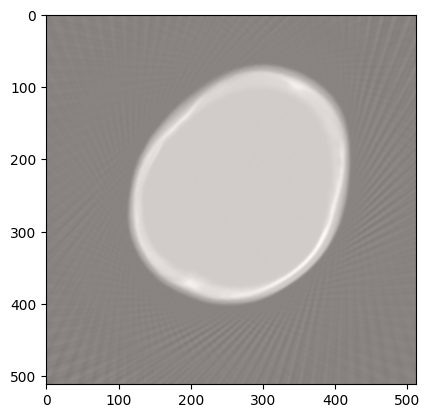

In [31]:
import matplotlib.pyplot as plt

idx = 0
mask = study.get_masks(idx)
imgs = study.get_images(idx)

plt.imshow(imgs.sum(axis=0), cmap='gray')
plt.imshow(mask.sum(axis=0), cmap='Reds', alpha=0.5)

In [ ]:
%pip install -q matplotlib ipywidgets

NameError: name 'masks' is not defined

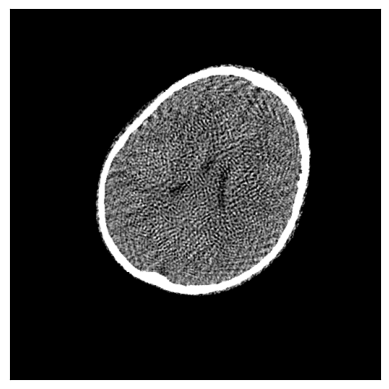

In [34]:
from utils import ctshow
import matplotlib.pyplot as plt
f, ax = plt.subplots()
idx = len(imgs) // 2
ctshow(imgs[idx], 'brain', fig=f, ax=ax)
ax.imshow(masks[idx], cmap='Reds', alpha=0.2)

In [35]:
from utils import scrollview
scrollview(imgs, 'brain')

interactive(children=(IntSlider(value=14, description='idx', max=28), Output()), _dom_classes=('widget-interac…